In [1]:
from transformers import AutoTokenizer
from tnqeet.constants import *

In [2]:
# Dotless characters
RASMS = [
    BAA_RASM,
    FAA_RASM,
    QAF_RASM,
    NOON_RASM,
]
RASMS
# RASMS = ARABIC_RASMS

['ٮ', 'ڡ', 'ٯ', 'ں']

In [3]:
def quick_check(model_id: str):
    """Check a tokenizer for rasm coverage and token-level rasm ratio.

    Returns dict with:
      - num_rasms_found: how many of the target RASMs appear anywhere in the vocab (0..len(RASMS))
      - coverage_pct: num_rasms_found / len(RASMS) * 100
      - token_ratio: % of vocab tokens containing at least one rasm character
    """
    print(f"\nChecking: {model_id}")
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    tokens = [tokenizer.convert_ids_to_tokens(i) for i in range(tokenizer.vocab_size)]
    vocab = [tokenizer.convert_tokens_to_string([t]).strip() for t in tokens]
    print(f"Vocabulary size: {len(vocab):,}")

    found_rasms = set()
    tokens_with_rasm = 0
    for token in vocab:
        token_rasms = {r for r in RASMS if r in token}
        if token_rasms:
            tokens_with_rasm += 1
            found_rasms.update(token_rasms)

    num_found = len(found_rasms)
    coverage_pct = 100.0 * num_found / len(RASMS)
    token_ratio = 100.0 * tokens_with_rasm / len(vocab) if vocab else 0.0

    print(f"Rasms found: {num_found}/{len(RASMS)} ({coverage_pct:.1f}%)")
    print(f"Tokens containing any rasm: {tokens_with_rasm:,}/{len(vocab):,} ({token_ratio:.4f}%)")
    print("=" * 60)
    return {
        "num_rasms_found": num_found,
        "coverage_pct": coverage_pct,
        "token_ratio": token_ratio,
    }

In [4]:
models = [
    'meta-llama/Llama-3.2-1B',
    'bigscience/bloom-1b7',
    'Qwen/Qwen2.5-0.5B',
    'CohereLabs/c4ai-command-a-03-2025',
    'google/gemma-3-270m-it',
    
    'aubmindlab/aragpt2-base',
    'core42/jais-13b',
    'humain-ai/ALLaM-7B-Instruct-preview',
    'FreedomIntelligence/AceGPT-7B',
    'silma-ai/SILMA-9B-Instruct-v1.0',
    'CohereLabs/c4ai-command-r7b-arabic-02-2025',
    'CohereLabs/aya-expanse-32b',
    
    
    'aubmindlab/bert-base-arabertv2',
    'CAMeL-Lab/bert-base-arabic-camelbert-msa',
    'UBC-NLP/MARBERT',
    
    'google-bert/bert-base-multilingual-cased',
    'FacebookAI/xlm-roberta-base',
    'microsoft/mdeberta-v3-base',
]

In [5]:
from huggingface_hub import notebook_login
notebook_login()

In [6]:
results = {}

for model in models:
    stats = quick_check(model)
    if stats is not None:
        short_name = model.split('/')[-1]
        results[short_name] = stats
results


Checking: meta-llama/Llama-3.2-1B
Vocabulary size: 128,000
Rasms found: 0/4 (0.0%)
Tokens containing any rasm: 0/128,000 (0.0000%)

Checking: bigscience/bloom-1b7
Vocabulary size: 250,680
Rasms found: 1/4 (25.0%)
Tokens containing any rasm: 243/250,680 (0.0969%)

Checking: Qwen/Qwen2.5-0.5B
Vocabulary size: 151,643
Rasms found: 2/4 (50.0%)
Tokens containing any rasm: 2/151,643 (0.0013%)

Checking: CohereLabs/c4ai-command-a-03-2025
Vocabulary size: 255,000
Rasms found: 0/4 (0.0%)
Tokens containing any rasm: 0/255,000 (0.0000%)

Checking: google/gemma-3-270m-it
Vocabulary size: 262,144
Rasms found: 2/4 (50.0%)
Tokens containing any rasm: 96/262,144 (0.0366%)

Checking: aubmindlab/aragpt2-base
Vocabulary size: 64,000
Rasms found: 0/4 (0.0%)
Tokens containing any rasm: 0/64,000 (0.0000%)

Checking: core42/jais-13b
Vocabulary size: 84,992
Rasms found: 0/4 (0.0%)
Tokens containing any rasm: 0/84,992 (0.0000%)

Checking: humain-ai/ALLaM-7B-Instruct-preview
Vocabulary size: 64,000
Rasms found

/raid_storage/SLURM/home/anonymous/Projects/tnqeet/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Vocabulary size: 250,101
Rasms found: 4/4 (100.0%)
Tokens containing any rasm: 32/250,101 (0.0128%)


{'Llama-3.2-1B': {'num_rasms_found': 0,
  'coverage_pct': 0.0,
  'token_ratio': 0.0},
 'bloom-1b7': {'num_rasms_found': 1,
  'coverage_pct': 25.0,
  'token_ratio': 0.09693633317376735},
 'Qwen2.5-0.5B': {'num_rasms_found': 2,
  'coverage_pct': 50.0,
  'token_ratio': 0.001318887123045574},
 'c4ai-command-a-03-2025': {'num_rasms_found': 0,
  'coverage_pct': 0.0,
  'token_ratio': 0.0},
 'gemma-3-270m-it': {'num_rasms_found': 2,
  'coverage_pct': 50.0,
  'token_ratio': 0.03662109375},
 'aragpt2-base': {'num_rasms_found': 0,
  'coverage_pct': 0.0,
  'token_ratio': 0.0},
 'jais-13b': {'num_rasms_found': 0, 'coverage_pct': 0.0, 'token_ratio': 0.0},
 'ALLaM-7B-Instruct-preview': {'num_rasms_found': 0,
  'coverage_pct': 0.0,
  'token_ratio': 0.0},
 'AceGPT-7B': {'num_rasms_found': 0, 'coverage_pct': 0.0, 'token_ratio': 0.0},
 'SILMA-9B-Instruct-v1.0': {'num_rasms_found': 3,
  'coverage_pct': 75.0,
  'token_ratio': 0.00390625},
 'c4ai-command-r7b-arabic-02-2025': {'num_rasms_found': 0,
  'covera

In [38]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def plot_dotless_ratios(
    model_stats=results,
    filename='tnqeet/notebooks/figures/llms_rasm_coverage.pdf',
    metric='token_ratio',
    figsize=None,
):
    """Publication-quality plot of rasm presence per tokenizer.

    X-axis: models grouped by number of rasms found (high → low), sorted by
            ``metric`` within each group, with dashed separators between
            groups.
    Y-axis: token_ratio shown on a 0–10 % scale (raw fractional percents are
            multiplied by 100 to avoid sub-1 labels like ``0.10``).
    Color: sequential viridis ramp keyed on # rasms found (0 = neutral gray).
    Bottom legend: each group sits directly under its own lines on the x-axis
            (shared transform). The 3-rasm group sits above the 4-rasm group
            in their shared column; the 0-rasm group has one header above two
            sub-columns of model names. Model names are left-aligned.
    """
    rc = {
        # Classic, publication-formal serif (Times-like) with safe Linux
        # fallbacks. mathtext uses the matching STIX glyphs.
        # 'font.family': 'serif',
        # 'font.serif': [
        #     'Times New Roman', 'Nimbus Roman', 'Liberation Serif',
        #     'Times', 'STIXGeneral', 'DejaVu Serif',
        # ],
        'mathtext.fontset': 'stix',
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'axes.linewidth': 0.8,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'legend.title_fontsize': 12,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
    }

    with mpl.rc_context(rc):
        cmap = plt.get_cmap('viridis')
        # Compressed to the darker half of viridis so the 4-rasm color
        # doesn't wash out on a white background.
        num_rasm_colors = {
            0: "#606060",
            1: cmap(0.10),
            2: cmap(0.30),
            3: cmap(0.50),
            4: cmap(0.70),
        }

        # Sort: groups by num_rasms_found desc, then metric desc within group.
        items = sorted(
            model_stats.items(),
            key=lambda kv: (-kv[1]['num_rasms_found'], -kv[1][metric]),
        )
        names = [name for name, _ in items]
        raw_values = [s[metric] for _, s in items]
        if metric == 'token_ratio':
            values = [v * 100 for v in raw_values]
        else:
            values = list(raw_values)
        rasm_counts = [s['num_rasms_found'] for _, s in items]
        n = len(names)
        model_colors = [num_rasm_colors.get(c, '#000000') for c in rasm_counts]
        group_boundaries = [
            i for i in range(1, n) if rasm_counts[i] != rasm_counts[i - 1]
        ]

        ordered_groups = sorted(set(rasm_counts), reverse=True)
        group_indices = {
            c: [i for i, rc in enumerate(rasm_counts) if rc == c]
            for c in ordered_groups
        }

        # Build legend columns. The 4-rasm and 3-rasm groups merge into one
        # column with 3 on top of 4; the 0-rasm group splits into 2 sub-cols
        # under a single header; everything else stands alone. Each column
        # records the x-axis range it has to sit beneath.
        legend_columns = []
        consumed = set()
        for g in ordered_groups:
            if g in consumed:
                continue
            if g == 4 and 3 in ordered_groups:
                merged = [3, 4]  # 3 displayed above 4
                consumed.update(merged)
                idxs = group_indices[3] + group_indices[4]
                legend_columns.append({
                    'groups': merged,
                    'x_min': min(idxs),
                    'x_max': max(idxs),
                    'sub_cols': 1,
                })
            elif g == 0:
                consumed.add(g)
                idxs = group_indices[g]
                legend_columns.append({
                    'groups': [g],
                    'x_min': min(idxs),
                    'x_max': max(idxs),
                    'sub_cols': 2,
                })
            else:
                consumed.add(g)
                idxs = group_indices[g]
                legend_columns.append({
                    'groups': [g],
                    'x_min': min(idxs),
                    'x_max': max(idxs),
                    'sub_cols': 1,
                })

        def col_rows(col):
            if col['sub_cols'] > 1:
                g = col['groups'][0]
                per_sub = -(-len(group_indices[g]) // col['sub_cols'])
                return 1 + per_sub  # 1 shared header + tallest sub-column
            return sum(1 + len(group_indices[g]) for g in col['groups'])

        max_rows = max(col_rows(col) for col in legend_columns)

        if figsize is None:
            # Wider so longer model names don't crowd neighbouring columns
            # at the larger legend font size.
            width = max(10.0, 0.80 * n + 1)
            height = 3.4 + 0.30 * max_rows
            figsize = (width, height)

        fig = plt.figure(figsize=figsize, constrained_layout=True)
        gs = fig.add_gridspec(2, 1, height_ratios=[3.4, 0.30 * max_rows])
        ax = fig.add_subplot(gs[0])
        ax_legend = fig.add_subplot(gs[1], sharex=ax)

        # ---------------- Plot ----------------
        y_max = max(values) if values else 1.0
        y_top = max(10.0, y_max * 1.18) if metric == 'token_ratio' else (
            y_max * 1.22 if y_max > 0 else 1.0
        )
        x = np.arange(n)

        for xi, yi, c in zip(x, values, model_colors):
            ax.plot([xi, xi], [0, yi], color=c, alpha=0.55,
                    linewidth=1.4, solid_capstyle='round', zorder=2)
            ax.scatter(xi, yi, s=70, c=[c], alpha=1.0,
                       edgecolors='white', linewidths=0.8, zorder=3)
            if metric == 'token_ratio':
                label = f'{yi:.1f}'
            else:
                label = f'{yi:.2f}' if y_max < 5 else f'{yi:.1f}'
            ax.annotate(label, xy=(xi, yi), xytext=(0, 4),
                        textcoords='offset points',
                        ha='center', va='bottom', fontsize=12, color='0.25')

        for b in group_boundaries:
            ax.axvline(b - 0.5, color='0.7',
                       linestyle=(0, (3, 3)), linewidth=0.7,
                       alpha=0.8, zorder=1)

        ax.set_ylim(-y_top * 0.04, y_top)
        ax.set_xlim(-0.7, n - 0.3)
        if metric == 'token_ratio':
            ylabel = 'Tokens containing rasm (%)'
        else:
            ylabel = 'Rasm coverage (%)'
        ax.set_ylabel(ylabel, fontweight='bold', labelpad=6)
        ax.set_xticks([])
        for side in ('top', 'right', 'bottom'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_color('0.4')
        ax.tick_params(axis='y', length=3, width=0.7, color='0.4')
        ax.grid(True, axis='y', alpha=0.25, linestyle=':', linewidth=0.6)
        ax.set_axisbelow(True)

        # ---------------- Legend block (aligned under each group) ----------
        ax_legend.set_ylim(0, 1)
        ax_legend.axis('off')
        row_height = 1.0 / max_rows
        left_pad = 0.4  # data-unit padding so labels don't kiss the separator
        name_fontsize = 12

        def draw_header(x_center, x_min, x_max, y_cursor, label, color):
            y_header = y_cursor - 0.5 * row_height
            ax_legend.text(
                x_center, y_header, label,
                ha='center', va='center', fontsize=12, fontweight='bold',
                color=color,
            )
            span = max(0.35, (x_max - x_min) / 2 + 0.25)
            ax_legend.plot(
                [x_center - span, x_center + span],
                [y_header - 0.42 * row_height,
                 y_header - 0.42 * row_height],
                color=color, linewidth=0.6, alpha=0.55,
            )

        for col in legend_columns:
            x_center = (col['x_min'] + col['x_max']) / 2

            if col['sub_cols'] > 1:
                # One header above several sub-columns of model names.
                g = col['groups'][0]
                color = num_rasm_colors[g]
                header_color = color if g != 0 else '0.35'

                draw_header(
                    x_center, col['x_min'], col['x_max'], 1.0,
                    f'{g} rasm{"s" if g != 1 else ""}', header_color,
                )

                idxs = group_indices[g]
                n_sub = col['sub_cols']
                per_sub = -(-len(idxs) // n_sub)
                width = col['x_max'] - col['x_min']
                # Cap the gap between sub-columns so a wide group (e.g. 0
                # rasms with 9 models) doesn't leave a big empty band
                # between its two name columns. Tuned so the longest name
                # in the left sub-column still has ~0.5 unit clearance.
                sub_spacing = min(width / n_sub, 3.5)
                for s in range(n_sub):
                    # Left edge of this sub-column (with a small left pad
                    # only on the very first sub-col so it clears the
                    # group separator dashed line).
                    sub_left = col['x_min'] + sub_spacing * s
                    if s == 0:
                        sub_left -= left_pad
                    y_sub = 1.0 - row_height  # start below the header
                    for idx in idxs[s * per_sub:(s + 1) * per_sub]:
                        y_row = y_sub - 0.5 * row_height
                        ax_legend.text(
                            sub_left, y_row, names[idx],
                            ha='left', va='center', fontsize=name_fontsize,
                            color=color,
                        )
                        y_sub -= row_height
            else:
                y_cursor = 1.0
                x_text = col['x_min'] - left_pad  # left-edge anchor
                for g in col['groups']:
                    color = num_rasm_colors[g]
                    header_color = color if g != 0 else '0.35'
                    draw_header(
                        x_center, col['x_min'], col['x_max'], y_cursor,
                        f'{g} rasm{"s" if g != 1 else ""}', header_color,
                    )
                    y_cursor -= row_height
                    for idx in group_indices[g]:
                        y_row = y_cursor - 0.5 * row_height
                        ax_legend.text(
                            x_text, y_row, names[idx],
                            ha='left', va='center', fontsize=name_fontsize,
                            color=color,
                        )
                        y_cursor -= row_height

        out_path = Path(filename).expanduser().resolve()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, bbox_inches='tight', format='pdf')
        print(f"✓ Saved: {out_path}")
        return fig

✓ Saved: /raid_storage/SLURM/home/anonymous/Projects/tnqeet/tnqeet/notebooks/figures/llms_rasm_coverage.pdf


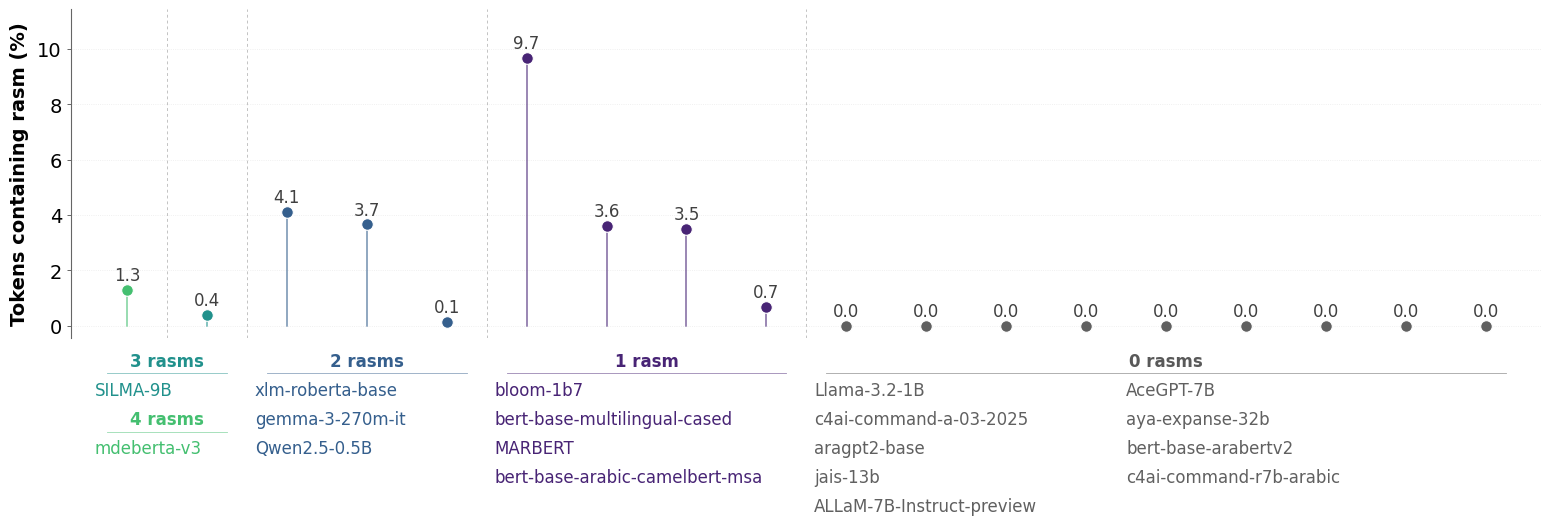

In [39]:
if 'SILMA-9B-Instruct-v1.0' in results:
    results['SILMA-9B'] = results.pop('SILMA-9B-Instruct-v1.0')
if 'mdeberta-v3-base' in results:
    results['mdeberta-v3'] = results.pop('mdeberta-v3-base')
if 'c4ai-command-r7b-arabic-02-2025' in results:
    results['c4ai-command-r7b-arabic'] = results.pop('c4ai-command-r7b-arabic-02-2025')
plot_dotless_ratios()